nom:Eljattioui
prenom: maryam
Master:GLCC

Résultat : Le nouveau fruit est classé comme une Pomme


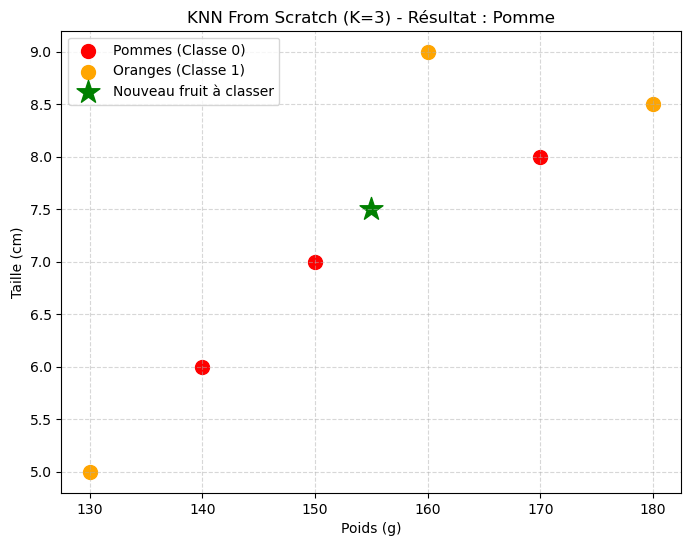

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# =================================================================
# 1. PRÉPARATION DES DONNÉES
# =================================================================
# X_train : Caractéristiques des fruits [Poids en grammes, Taille en cm]
X_train = np.array([[150, 7], [170, 8], [140, 6], [130, 5], [160, 9], [180, 8.5]])
# y_train : Classes correspondantes (0 = Pomme, 1 = Orange)
y_train = np.array([0, 0, 0, 1, 1, 1])

# Point à prédire (X_new) que l'on souhaite classifier (Un nouveau fruit)
X_new = np.array([155, 7.5])

# =================================================================
# 2. ALGORITHME KNN FROM SCRATCH
# =================================================================

def euclidean_distance(x1, x2):
    """
    Calcule la distance Euclidienne entre deux points.
    Formule : sqrt( sum( (xi - yi)^2 ) )
    C'est la mesure de similarité la plus commune en KNN.
    """
    return np.sqrt(np.sum((x1 - x2)**2))

def knn_predict(X_train, y_train, x_new, k=3):
    # ÉTAPE 1 : Calcul des distances
    # On mesure la distance entre le nouveau point et CHAQUE point du dataset d'entraînement.
    distances = [euclidean_distance(x_new, x_point) for x_point in X_train]
    
    # ÉTAPE 2 : Identification des voisins
    # np.argsort renvoie les indices qui trieraient le tableau par ordre croissant.
    # On ne garde que les 'k' premiers indices (les plus proches).
    k_indices = np.argsort(distances)[:k]
    
    # ÉTAPE 3 : Extraction des étiquettes (Labels)
    # On regarde la classe (0 ou 1) de ces k voisins les plus proches.
    k_nearest_labels = [y_train[i] for i in k_indices]
    
    # ÉTAPE 4 : Vote majoritaire
    # On compte quelle classe est la plus représentée parmi les voisins.
    # Counter(...).most_common(1) renvoie la classe dominante (ex: la classe 0 est présente 2 fois sur 3).
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]

# Lancement de la prédiction avec K=3
# On regarde les 3 voisins les plus proches pour décider.
prediction = knn_predict(X_train, y_train, X_new, k=3)
label = "Orange" if prediction == 1 else "Pomme"
print(f"Résultat : Le nouveau fruit est classé comme une {label}")

# =================================================================
# 3. VISUALISATION DES VOISINS
# =================================================================
plt.figure(figsize=(8, 6))

# Affichage des classes connues
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], color='red', s=100, label='Pommes (Classe 0)')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], color='orange', s=100, label='Oranges (Classe 1)')

# Affichage du point à prédire (en forme d'étoile verte)
plt.scatter(X_new[0], X_new[1], color='green', marker='*', s=300, label='Nouveau fruit à classer')

# Mise en forme académique
plt.title(f'KNN From Scratch (K=3) - Résultat : {label}')
plt.xlabel('Poids (g)')
plt.ylabel('Taille (cm)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()